In [1]:
from pathlib import Path

import numpy as np
from dataeval.data import ClassFilter, Limit, Shuffle, View
from datamaite import load_ic
from maite_datasets.image_classification import MilitaryVehicles

data_root = Path("./data")
MilitaryVehicles(root=data_root, image_set="base", download=True)
MilitaryVehicles(root=data_root, image_set="train", as_datamaite=True)

vehicles_raw = load_ic(data_root / "militaryvehicles_datamaite_train" / "train", dataset_format="huggingface_vision")
index2label = vehicles_raw.metadata.get("index2label", {})

# The category this collection cycle never captured.
AIR_DEFENSE = {"30N6E", "Iskander", "Pantsir-S1", "Rs-24"}
collected_classes = [i for i, name in index2label.items() if name not in AIR_DEFENSE]

# `ClassFilter` enforces the gap by filtering on sample labels.
# `Shuffle` and `Limit` sample the result for faster execution.
collected = View(vehicles_raw, [ClassFilter(collected_classes), Shuffle(seed=0), Limit(1500)])

print(f"Full collection:  {len(vehicles_raw)} frames, {len(index2label)} types")
print(f"After the gap:    {len(collected)} frames, {len(collected_classes)} types")
print(f"Never collected:  {sorted(AIR_DEFENSE)}")

/builds/jatic/aria/dataeval-flow/.nox/docs/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Full collection:  7823 frames, 24 types
After the gap:    1500 frames, 20 types
Never collected:  ['30N6E', 'Iskander', 'Pantsir-S1', 'Rs-24']


In [2]:
labels = np.array([int(np.argmax(collected[i][1])) for i in range(len(collected))])
class_counts = {index2label[c]: int((labels == c).sum()) for c in sorted(set(labels.tolist()))}
ordered = sorted(class_counts.items(), key=lambda kv: -kv[1])

largest, smallest = ordered[0], ordered[-1]
ratio = largest[1] / smallest[1]
print(f"Largest class:  {largest[0]} ({largest[1]})")
print(f"Smallest class: {smallest[0]} ({smallest[1]})")
print(f"Imbalance ratio: {ratio:.2f}:1")

Largest class:  BTR-80 (94)
Smallest class: T-90 (53)
Imbalance ratio: 1.77:1


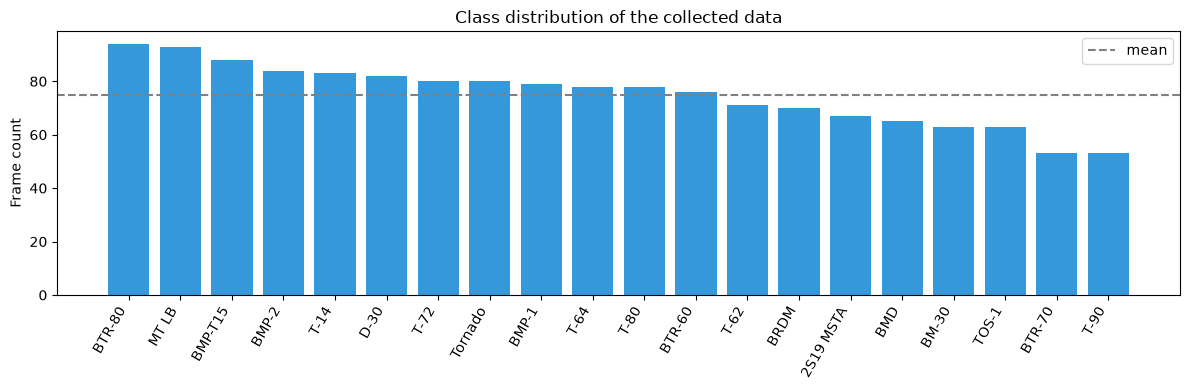

In [3]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 4))
names = [n for n, _ in ordered]
values = [v for _, v in ordered]
ax.bar(names, values, color="#3498db")
ax.axhline(y=float(np.mean(values)), color="gray", linestyle="--", label="mean")
ax.set_ylabel("Frame count")
ax.set_title("Class distribution of the collected data")
ax.tick_params(axis="x", rotation=60)
for tick in ax.get_xticklabels():
    tick.set_horizontalalignment("right")
ax.legend()
plt.tight_layout()
plt.show()

In [4]:
from dataeval_flow import PipelineConfig, run_task
from dataeval_flow.config import DatasetProtocolConfig, MetadataPolicyConfig, SourceConfig, TaskConfig
from dataeval_flow.workflows.data_coverage import DataCoverageConfig, DataCoverageHealthThresholds

vehicle_factors = MetadataPolicyConfig(
    name="vehicle_factors",
    # Nothing in this dataset's own per-sample metadata is a collection condition:
    # `id` is unique per frame (so it looks perfectly class-predictive) and height and
    # width describe the crop, not the scene. Ask for measured image statistics instead.
    intrinsic_factors=["visual", "pixel"],
    exclude=["id", "height", "width"],
    # Explicitly declared bins keep factor cuts consistent across runs.
    continuous_factor_bins={
        "brightness": 5,
        "contrast": 5,
        "darkness": 5,
        "entropy": 5,
        "kurtosis": 5,
        "mean": 5,
        "sharpness": 5,
        "skew": 5,
        "std": 5,
        "var": 5,
        "zeros": 5,
    },
)

metadata_only_workflow = DataCoverageConfig(
    name="coverage-metadata-only",
    metadata="vehicle_factors",
    run_gap_analysis=True,
    gap_min_representation=5,  # Flag class-factor-value combos with < 5 samples
    balance=True,
    diversity_method="simpson",
    health_thresholds=DataCoverageHealthThresholds(
        class_imbalance_ratio=3.0,  # Catch moderate class imbalance
        gap_count=2,  # Warn if >= 2 gaps found
    ),
)

task_metadata = TaskConfig(
    name="vehicles-coverage-metadata",
    workflow="coverage-metadata-only",
    sources="vehicles_src",
    # No extractor for metadata-only pass
)

config_metadata = PipelineConfig(
    metadata=[vehicle_factors],
    datasets=[
        DatasetProtocolConfig(name="vehicles_collected", format="maite", dataset=collected),
    ],
    sources=[
        SourceConfig(name="vehicles_src", dataset="vehicles_collected"),
    ],
    workflows=[metadata_only_workflow],
    tasks=[task_metadata],
)

In [5]:
result_metadata = run_task(task_metadata, config_metadata, cache_dir=Path("./cache"))

/builds/jatic/aria/dataeval-flow/src/dataeval_flow/workflows/data_coverage/_workflow.py:558: UserWarning: Declared cuts left bins unused: kurtosis (4 of 5 bins hold rows). The encoding still applies and the codes are unchanged; this is the data no longer matching the policy, not an error. Call reencode() to refit — which moves codes — or leave it and read the empty groups as the finding they are.
  bal_result = Balance(factor_source=policy.factor_source).evaluate(metadata)


In [6]:
print(result_metadata.report())


  COVERAGE ANALYSIS: 1500 SAMPLES, DEFICIT=266.
  Timestamp:    2026-09-25T21:18:36.289858+00:00
  Duration:     0.63s
  Source:       vehicles_src (vehicles_collected)
------------------------------------------------------------------------------------------

  SUMMARY
  -------
  Label Distribution .................. 20 classes, ratio 1.8:1, 4 with no samples  [!!]
  Metadata Distribution ......... 12 factors, balance computed, diversity computed  [..]
  Metadata Coverage Gaps ............................ No significant gaps detected  [ok]
  Class Balance Worklist ........................... 6 classes short · deficit 266  [..]

  Health: 1 warning(s) [!!] — review flagged findings

  LABEL DISTRIBUTION                            20 classes, ratio 1.8:1, 4 with no samples
  20 classes with imbalance ratio 1.8:1. 0 images have no labels. 4 declared class(es) have zero samples: 30N6E, Iskander, Pantsir-S1, Rs-24.

  Class       Count     %
  ----------  -----  ----
  BTR-80         94 

In [7]:
raw = result_metadata.output.raw

ld = raw.label_distribution
print(f"Number of classes: {ld.num_classes}")
print(f"Empty images: {len(ld.empty_images)}")
print("\nClass distribution (five largest, five smallest):")
by_size = sorted(ld.class_distribution.items(), key=lambda x: x[1], reverse=True)
for cls, count in by_size[:5]:
    print(f"  {cls:<26} {count}")
print("  ...")
for cls, count in by_size[-5:]:
    print(f"  {cls:<26} {count}")

Number of classes: 20
Empty images: 0

Class distribution (five largest, five smallest):
  BTR-80                     94
  MT LB                      93
  BMP-T15                    88
  BMP-2                      84
  T-14                       83
  ...
  T-90                       53
  30N6E                      0
  Iskander                   0
  Pantsir-S1                 0
  Rs-24                      0


In [8]:
# Metadata gaps: evaluate if a class was only imaged under narrow conditions
if raw.metadata_gaps and raw.metadata_gaps.gaps:
    print(f"Metadata coverage gaps: {len(raw.metadata_gaps.gaps)}\n")

    print("  Mutual information (class -> factor), five strongest:")
    mi = sorted(raw.metadata_gaps.mutual_info_class_to_factor.items(), key=lambda x: -x[1])
    for factor, value in mi[:5]:
        print(f"    {factor:<28} {value:.4f}")

    print("\n  Gap details (first ten):")
    for gap in raw.metadata_gaps.gaps[:10]:
        print(
            f"    {gap.class_name:<14} x {gap.factor_name}={gap.factor_value}: "
            f"count={gap.class_count}, expected={gap.expected_count:.1f}, "
            f"deficit={gap.deficit:.0%}"
        )
else:
    print("No metadata gaps detected.")

No metadata gaps detected.


In [9]:
import json

print(json.dumps(MilitaryVehicles.hierarchy, indent=2)[:900] + "\n...")

{
  "vehicle": {
    "military": {
      "land vehicle": {
        "Tank": [
          "T-14",
          "T-62",
          "T-64",
          "T-72",
          "T-80",
          "T-90"
        ],
        "BMP": [
          "BMP-1",
          "BMP-2",
          "BMP-T15"
        ],
        "BTR": [
          "BRDM",
          "BTR-60",
          "BTR-70",
          "BTR-80"
        ],
        "Self Propelled Artillery": [
          "2S19 MSTA",
          "BM-30",
          "D-30",
          "Tornado",
          "TOS-1"
        ],
        "Air Defense": [
          "30N6E",
          "Iskander",
          "Pantsir-S1",
          "Rs-24"
        ],
        "MT LB": [
          "MT LB"
        ],
        "BMD": [
          "BMD"
        ]
      },
      "watercraft": null,
      "aircraft": null
    }
  }
}
...


In [10]:
vehicle_ontology = MilitaryVehicles.hierarchy

ontology_workflow = metadata_only_workflow.model_copy(
    update={"name": "coverage-ontology", "ontology": vehicle_ontology},
)

task_ontology = TaskConfig(
    name="vehicles-coverage-ontology",
    workflow="coverage-ontology",
    sources="vehicles_src",
)

config_ontology = PipelineConfig(
    metadata=config_metadata.metadata,
    datasets=config_metadata.datasets,
    sources=config_metadata.sources,
    workflows=[ontology_workflow],
    tasks=[task_ontology],
)

result_ontology = run_task(task_ontology, config_ontology, cache_dir=Path("./cache"))
print(result_ontology.report())

/builds/jatic/aria/dataeval-flow/src/dataeval_flow/workflows/data_coverage/_workflow.py:558: UserWarning: Declared cuts left bins unused: kurtosis (4 of 5 bins hold rows). The encoding still applies and the codes are unchanged; this is the data no longer matching the policy, not an error. Call reencode() to refit — which moves codes — or leave it and read the empty groups as the finding they are.
  bal_result = Balance(factor_source=policy.factor_source).evaluate(metadata)



  COVERAGE ANALYSIS: 1500 SAMPLES, DEFICIT=358.
  Timestamp:    2026-09-25T21:18:36.969255+00:00
  Duration:     0.62s
  Source:       vehicles_src (vehicles_collected)
------------------------------------------------------------------------------------------

  SUMMARY
  -------
  Label Distribution .................. 20 classes, ratio 1.8:1, 4 with no samples  [!!]
  Metadata Distribution ......... 12 factors, balance computed, diversity computed  [..]
  Metadata Coverage Gaps ............................ No significant gaps detected  [ok]
  Label Space Coverage .......... leaf coverage 76.9% · 6 to acquire · deficit 358  [!!]
  Label Conformance ..................................................... conforms  [ok]
  Label Alignment ...............................................................   [ok]
  Ontology Structure ...... 34 concepts, 26 leaves, depth 4 · 1 single-child links  [..]

  Health: 2 warning(s) [!!] — review flagged findings

  LABEL DISTRIBUTION                   

In [11]:
onto = result_ontology.output.raw.ontology
print(f"source: {onto.source} (synthesized={onto.synthesized})")
print(f"leaf coverage: {onto.representation.leaf_coverage:.0%}")
print(f"total deficit: {onto.representation.total_deficit} labels\n")

print("Dark branches: whole regions of the label space with zero examples:")
for branch in onto.representation.dark_branches:
    print(f"  {branch.label:<16} {branch.leaves} leaf class(es), zero examples")

print("\nTop of the collection worklist:")
for row in onto.representation.worklist[:8]:
    print(f"  {row.label:>14}  {row.action:<8} have {row.count:>4}, want {row.target:>4}")

source: inline (synthesized=False)
leaf coverage: 77%
total deficit: 358 labels

Dark branches: whole regions of the label space with zero examples:
  Air Defense      4 leaf class(es), zero examples

Top of the collection worklist:
           30N6E  acquire  have    0, want   58
        Iskander  acquire  have    0, want   58
      Pantsir-S1  acquire  have    0, want   58
           Rs-24  acquire  have    0, want   58
        aircraft  acquire  have    0, want   58
      watercraft  acquire  have    0, want   58
          BTR-70  augment  have   53, want   58
            T-90  augment  have   53, want   58


In [12]:
from dataeval import Ontology
from dataeval.core import label_reconciliation

# The workflow builds this automatically from the `ontology` field. You can also
# construct the object directly to reconcile arbitrary label lists against it.
ontology_obj = Ontology.from_hierarchy(vehicle_ontology)
check = label_reconciliation(["T-72", "BTR-80", "T72", "technical"], ontology_obj)
print("matched:  ", dict(check["matched"]))
print("unmatched:", list(check["unmatched"]))

matched:   {'T-72': 'T-72', 'BTR-80': 'BTR-80'}
unmatched: ['T72', 'technical']


In [13]:
from dataeval.config import set_max_processes

from dataeval_flow.config.extractors import BoVWExtractorConfig

set_max_processes(8)

full_workflow = DataCoverageConfig(
    name="coverage-full",
    metadata="vehicle_factors",
    ontology=vehicle_ontology,  # carry the label space forward
    coverage_method="adaptive",
    coverage_percent=0.01,  # adaptive: flag the sparsest 1% of observations
    num_observations=50,  # Number of neighbors for coverage analysis
    run_completeness=True,  # Measure dimensional completeness
    run_gap_analysis=True,
    balance=True,
    diversity_method="simpson",
    health_thresholds=DataCoverageHealthThresholds(
        uncovered_rate=10.0,  # Warn if > 10% uncovered in embedding space
        completeness_score=0.5,  # Warn if completeness < 0.5
        class_imbalance_ratio=3.0,
        gap_count=2,
    ),
)

task_full = TaskConfig(
    name="vehicles-coverage-full",
    workflow="coverage-full",
    sources="vehicles_src",
    extractor="bovw_ext",
)

config_full = PipelineConfig(
    metadata=config_metadata.metadata,
    datasets=config_metadata.datasets,
    sources=config_metadata.sources,
    extractors=[
        BoVWExtractorConfig(name="bovw_ext", vocab_size=256, batch_size=32),
    ],
    workflows=[full_workflow],
    tasks=[task_full],
)

In [14]:
result_full = run_task(task_full, config_full, cache_dir=Path("./cache"))

/builds/jatic/aria/dataeval-flow/src/dataeval_flow/workflows/data_coverage/_workflow.py:558: UserWarning: Declared cuts left bins unused: kurtosis (4 of 5 bins hold rows). The encoding still applies and the codes are unchanged; this is the data no longer matching the policy, not an error. Call reencode() to refit — which moves codes — or leave it and read the empty groups as the finding they are.
  bal_result = Balance(factor_source=policy.factor_source).evaluate(metadata)


In [15]:
print(result_full.report())


  COVERAGE ANALYSIS: 1500 SAMPLES, 15 UNCOVERED, COMPLETENESS=0.59, DEFICIT=358.
  Timestamp:    2026-09-25T21:24:27.486796+00:00
  Duration:     350.45s
  Source:       vehicles_src (vehicles_collected)
  Model:        bovw_ext (bovw)
------------------------------------------------------------------------------------------

  SUMMARY
  -------
  Embedding Coverage ......................................... 15 uncovered (1.0%)  [..]
  Dimensional Completeness ................................... Completeness: 0.591  [..]
  Label Distribution .................. 20 classes, ratio 1.8:1, 4 with no samples  [!!]
  Metadata Distribution ......... 12 factors, balance computed, diversity computed  [..]
  Metadata Coverage Gaps ............................ No significant gaps detected  [ok]
  Label Space Coverage .......... leaf coverage 76.9% · 6 to acquire · deficit 358  [!!]
  Label Conformance ..................................................... conforms  [ok]
  Label Alignment ..........

In [16]:
raw_full = result_full.output.raw

if raw_full.coverage:
    cov = raw_full.coverage
    print(f"Method: {cov.method}")
    print(f"Uncovered: {cov.uncovered_count} ({cov.uncovered_rate:.1%})\n")
    print(f"{'class':>14}  {'count':>5}  {'disp':>6}  {'iso':>6}  {'nearDup':>7}")

    def _fmt(v: float | None) -> str:
        return "  -   " if v is None else f"{v:6.2f}"

    for row in sorted(cov.per_class, key=lambda r: -(r.near_duplicate_fraction or 0.0)):
        print(
            f"{row.class_name:>14}  {row.count:>5}  {_fmt(row.dispersion)}  "
            f"{_fmt(row.isotropy)}  {_fmt(row.near_duplicate_fraction):>7}"
        )
elif raw_full.coverage_skipped_reason:
    print(f"Embedding coverage skipped: {raw_full.coverage_skipped_reason}")
else:
    print("No embedding coverage (extractor not configured)")

print()

if raw_full.completeness:
    comp = raw_full.completeness
    print("Dimensional Completeness:")
    print(f"  Score: {comp.completeness_score:.3f}")
    print(f"  Nearest neighbor pairs: {len(comp.nearest_neighbor_pairs)}")
else:
    print("No completeness data (extractor not configured)")

Method: adaptive
Uncovered: 15 (1.0%)

         class  count    disp     iso  nearDup
       Tornado     80    1.01    -        0.01
         TOS-1     63    0.97    -        0.00
         BMP-1     79    0.97    -        0.00
          T-80     78    0.98    -        0.00
          T-90     53    0.98    -        0.00
         BM-30     63    0.98    -        0.00
          T-72     80    0.98    -        0.00
          T-62     71    0.99    -        0.00
          BRDM     70    0.99    -        0.00
        BTR-70     53    1.00    -        0.00
       BMP-T15     88    1.00    -        0.00
     2S19 MSTA     67    1.00    -        0.00
          T-14     83    1.00    -        0.00
         BMP-2     84    1.01    -        0.00
        BTR-60     76    1.01    -        0.00
         MT LB     93    1.02    -        0.00
          T-64     78    1.02    -        0.00
          D-30     82    1.02    -        0.00
        BTR-80     94    1.02    -        0.00
           BMD     65

In [17]:
strict_thresholds = DataCoverageHealthThresholds(
    uncovered_rate=5.0,
    completeness_score=0.6,
    class_imbalance_ratio=2.0,
    gap_count=1,
    min_dispersion=0.7,
    min_isotropy=0.7,
    max_near_duplicate_fraction=0.02,
    leaf_coverage=0.95,
    dark_branch_count=0,
    unmatched_class_count=0,
)

strict_workflow = full_workflow.model_copy(
    update={"name": "coverage-strict", "health_thresholds": strict_thresholds},
)

task_strict = TaskConfig(
    name="vehicles-coverage-strict",
    workflow="coverage-strict",
    sources="vehicles_src",
    extractor="bovw_ext",
)

config_strict = PipelineConfig(
    metadata=config_full.metadata,
    datasets=config_full.datasets,
    sources=config_full.sources,
    extractors=config_full.extractors,
    workflows=[full_workflow, strict_workflow],
    tasks=[task_strict],
)

result_strict = run_task(task_strict, config_strict, cache_dir=Path("./cache"))
print(result_strict.report())

/builds/jatic/aria/dataeval-flow/src/dataeval_flow/workflows/data_coverage/_workflow.py:558: UserWarning: Declared cuts left bins unused: kurtosis (4 of 5 bins hold rows). The encoding still applies and the codes are unchanged; this is the data no longer matching the policy, not an error. Call reencode() to refit — which moves codes — or leave it and read the empty groups as the finding they are.
  bal_result = Balance(factor_source=policy.factor_source).evaluate(metadata)



  COVERAGE ANALYSIS: 1500 SAMPLES, 15 UNCOVERED, COMPLETENESS=0.57, DEFICIT=358.
  Timestamp:    2026-09-25T21:29:27.580040+00:00
  Duration:     300.04s
  Source:       vehicles_src (vehicles_collected)
  Model:        bovw_ext (bovw)
------------------------------------------------------------------------------------------

  SUMMARY
  -------
  Embedding Coverage ......................................... 15 uncovered (1.0%)  [..]
  Dimensional Completeness ................................... Completeness: 0.567  [!!]
  Label Distribution .................. 20 classes, ratio 1.8:1, 4 with no samples  [!!]
  Metadata Distribution ......... 12 factors, balance computed, diversity computed  [..]
  Metadata Coverage Gaps ............................ No significant gaps detected  [ok]
  Label Space Coverage .......... leaf coverage 76.9% · 6 to acquire · deficit 358  [!!]
  Label Conformance ..................................................... conforms  [ok]
  Label Alignment ..........

In [18]:
json_str = result_full.export(fmt="json")
print(f"JSON output: {len(json_str)} characters")
print(json_str[:500] + "\n...")

JSON output: 270004 characters
{
  "kind": "workflow",
  "metadata": {
    "version": "1.0",
    "timestamp": "2026-09-25T21:24:27.486796Z",
    "dataset_id": "vehicles_collected",
    "label_source": "protocol",
    "model_id": "bovw_ext (bovw)",
    "preprocessor_id": null,
    "selection_id": null,
    "source_descriptions": [
      "vehicles_src (vehicles_collected)"
    ],
    "resolved_config": {
      "sources": [
        {
          "name": "vehicles_src",
          "dataset": "vehicles_collected",
          "dataset_
...
